# Network Evolution Exploration

This notebook provides a toolkit to explore, analyze, and visualize the network topology and metrics stored in Google Cloud Spanner. It tracks the evolution of the network over time using the SCD Type 2 snapshots.

## Objectives
1. **Ingest Snapshots**: Fetch historical network states from Spanner.
2. **Analyze Evolution**: Track how metrics (CPU, Utilisation, Routes) change over time.
3. **Visualize Topology**: Graph the physical and logical connectivity.
4. **Identify Trends**: Look for anomalies or patterns in the historical data.

## 1. Setup and Configuration

In [1]:
import os
import sys
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from typing import Dict, List

# Ensure the gnn/src directory is in the Python path
src_path = str((Path.cwd().resolve().parent / "src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from utils.data import SpannerDataset
from utils.gnn_utils import GraphBuilder, NODE_TYPES, EDGE_TYPES

# Spanner Configuration
PROJECT_ID = os.getenv("GOOGLE_CLOUD_PROJECT", "agents-1234")
INSTANCE_ID = os.getenv("SPANNER_INSTANCE", "networktopology-instance")
DATABASE_ID = os.getenv("SPANNER_DATABASE", "networktopology-db")

# Credential path
_local_creds = str((Path.cwd().resolve().parent / "src" / "networkagent.json").resolve())
if os.path.exists(_local_creds):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = _local_creds
    print(f"Using service-account credentials: {_local_creds}")

print(f"Target Project: {PROJECT_ID}")
print(f"Target Database: {INSTANCE_ID}/{DATABASE_ID}")

Using service-account credentials: /Users/alvarossl/Documents/bt_gnn/gnnsandbox/gnn/src/networkagent.json
Target Project: agents-1234
Target Database: networktopology-instance/networktopology-db


## 2. Ingest Historical Data

We will fetch multiple snapshots to see how the network has evolved.

In [2]:
NUM_SNAPSHOTS = 50  # Let's look at ~4 hours of history
INTERVAL_MINUTES = 5

dataset = SpannerDataset(
    instance_id=INSTANCE_ID,
    database_id=DATABASE_ID,
    num_snapshots=NUM_SNAPSHOTS,
    interval_minutes=INTERVAL_MINUTES,
    project_id=PROJECT_ID
)

print("Fetching timestamps...")
timestamps = dataset._get_timestamps()

snapshots = []
for ts in timestamps:
    try:
        snap = dataset.fetch_snapshot(ts)
        snapshots.append(snap)
    except Exception as e:
        print(f"Error fetching snapshot at {ts}: {e}")

print(f"Ingested {len(snapshots)} snapshots.")

# Compute temporal features (gradients, deltas)
SpannerDataset.compute_temporal_features(snapshots, interval_seconds=INTERVAL_MINUTES * 60)
print("Temporal features computed.")

Fetching timestamps...
Ingested 50 snapshots.
Temporal features computed.


## 3. Analyze Network Evolution

We'll convert the snapshot data into DataFrames for easier time-series analysis.

In [3]:
router_data = []
interface_data = []

for snap in snapshots:
    ts = snap['timestamp']
    for node in snap['nodes']:
        if node['type'] == 'router':
            router_data.append({
                'timestamp': ts,
                'id': node['id'],
                'hostname': node['hostname'],
                'role': node['role'],
                'cpu': node['cpu'],
                'mem': node['mem'],
                'ospf_routes': node['ospf_num_routes']
            })
        elif node['type'] == 'interface':
            interface_data.append({
                'timestamp': ts,
                'id': node['id'],
                'name': node['name'],
                'device_id': node['device_id'],
                'tx_util': node['tx_util'],
                'rx_util': node['rx_util'],
                'rx_err_gradient': node['rx_err_gradient']
            })

df_routers = pd.DataFrame(router_data)
df_ifaces = pd.DataFrame(interface_data)
df_routers['timestamp'] = pd.to_datetime(df_routers['timestamp'])
df_ifaces['timestamp'] = pd.to_datetime(df_ifaces['timestamp'])

print("Router Data Sample:")
display(df_routers.head())
print("\nInterface Data Sample:")
display(df_ifaces.head())

Router Data Sample:


,timestamp,id,hostname,role,cpu,mem,ospf_routes
0,2026-04-14 15:06:39.036447,router:ce1-hub,ce1-hub,CE,0.0,0.0,0.0
1,2026-04-14 15:06:39.036447,router:ce1-spoke,ce1-spoke,CE,0.0,0.0,0.0
2,2026-04-14 15:06:39.036447,router:ce2-spoke,ce2-spoke,CE,0.0,0.0,0.0
3,2026-04-14 15:06:39.036447,router:ce3-spoke,ce3-spoke,CE,0.0,0.0,0.0
4,2026-04-14 15:06:39.036447,router:p1,p1,P,0.0,0.0,0.0



Interface Data Sample:


,timestamp,id,name,device_id,tx_util,rx_util,rx_err_gradient
0,2026-04-14 15:06:39.036447,router:ce1-hub:interface:eth0,eth0,router:ce1-hub,0.0,0.0,0.0
1,2026-04-14 15:06:39.036447,router:ce1-hub:interface:eth1,eth1,router:ce1-hub,0.0,0.0,0.0
2,2026-04-14 15:06:39.036447,router:ce1-hub:interface:eth2,eth2,router:ce1-hub,0.0,0.0,0.0
3,2026-04-14 15:06:39.036447,router:ce1-hub:interface:lo,lo,router:ce1-hub,0.0,0.0,0.0
4,2026-04-14 15:06:39.036447,router:ce1-spoke:interface:eth0,eth0,router:ce1-spoke,0.0,0.0,0.0


### 3.1. Visualizing Metric Evolution

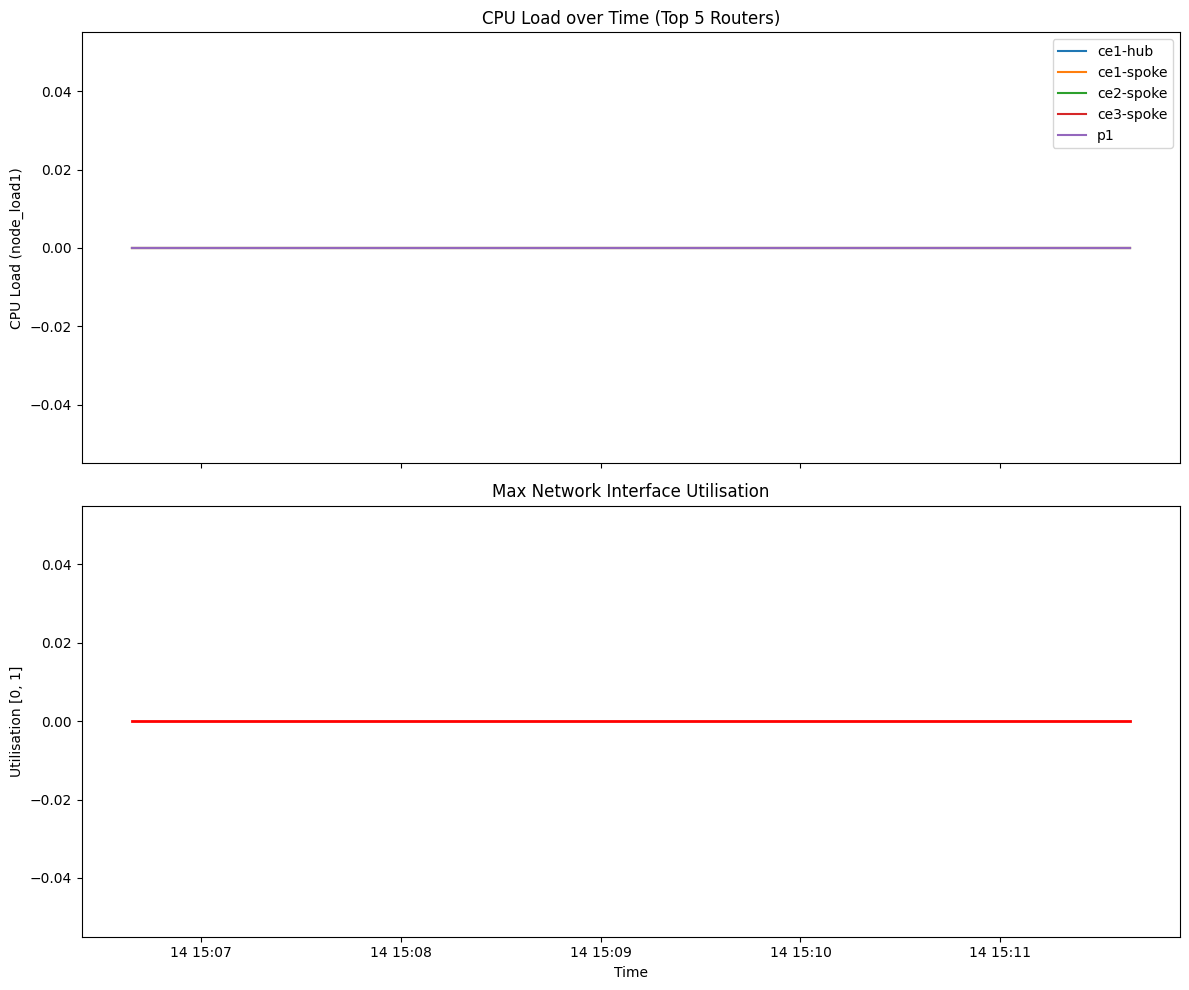

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot CPU for top routers
top_routers = df_routers.groupby('hostname')['cpu'].mean().nlargest(5).index
for router in top_routers:
    subset = df_routers[df_routers['hostname'] == router]
    ax1.plot(subset['timestamp'], subset['cpu'], label=router)
ax1.set_title("CPU Load over Time (Top 5 Routers)")
ax1.set_ylabel("CPU Load (node_load1)")
ax1.legend()

# Plot Max Utilisation across all interfaces
df_ifaces['max_util'] = df_ifaces[['tx_util', 'rx_util']].max(axis=1)
df_ifaces_pivot = df_ifaces.pivot(index='timestamp', columns='id', values='max_util')
ax2.plot(df_ifaces_pivot.index, df_ifaces_pivot.max(axis=1), color='red', linewidth=2, label="Network Max Util")
ax2.fill_between(df_ifaces_pivot.index, df_ifaces_pivot.mean(axis=1), df_ifaces_pivot.max(axis=1), alpha=0.2, color='red')
ax2.set_title("Max Network Interface Utilisation")
ax2.set_ylabel("Utilisation [0, 1]")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

## 4. Graph Visualization

Visualize the network topology using `networkx` based on the latest snapshot.

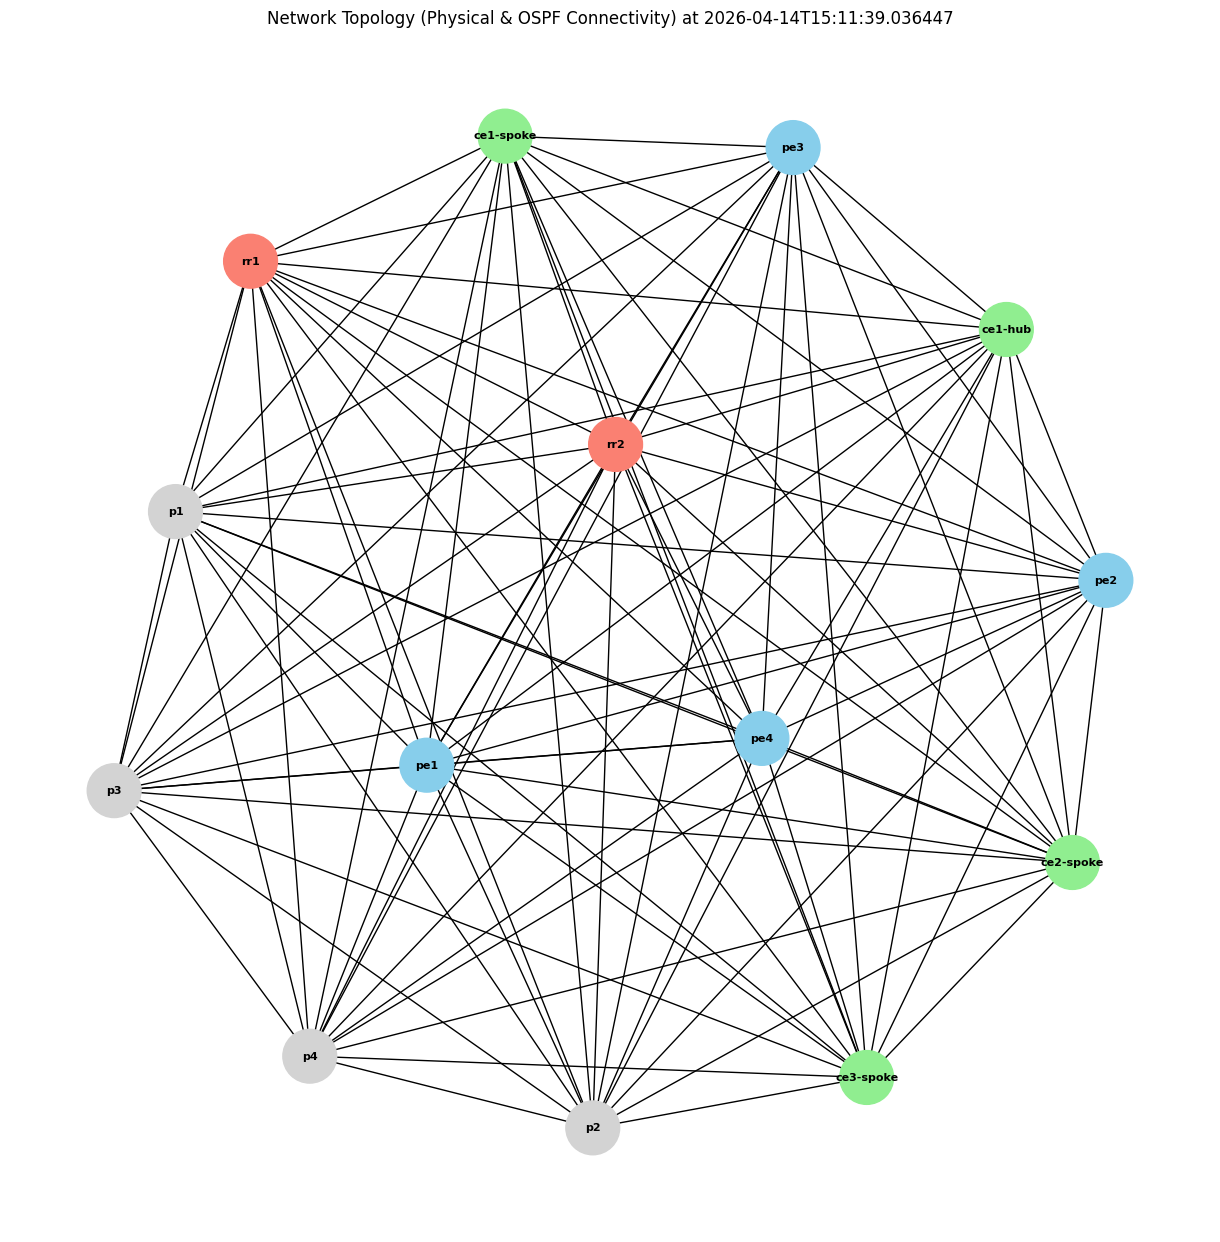

In [5]:
if snapshots:
    latest_snap = snapshots[-1]
    G = nx.Graph()
    
    # Add Router nodes
    for node in latest_snap['nodes']:
        if node['type'] == 'router':
            G.add_node(node['id'], label=node['hostname'], type='router', role=node['role'])
    
    # Add Physical connectivity (interface -> interface -> parent routers)
    # To simplify the visualization, we'll map connected_to edges directly between routers
    iface_to_router = {n['id']: n['device_id'] for n in latest_snap['nodes'] if n['type'] == 'interface'}
    
    for edge in latest_snap['edges']:
        if edge['relation'] == 'connected_to':
            u_router = iface_to_router.get(edge['source'])
            v_router = iface_to_router.get(edge['target'])
            if u_router and v_router and u_router != v_router:
                G.add_edge(u_router, v_router, type='physical')
        elif edge['relation'] == 'ospf_peer':
            G.add_edge(edge['source'], edge['target'], type='ospf')

    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, k=0.5, iterations=50)
    
    # Color by role
    role_colors = {'P': 'lightgray', 'PE': 'skyblue', 'RR': 'salmon', 'CE': 'lightgreen'}
    colors = [role_colors.get(G.nodes[n].get('role'), 'white') for n in G.nodes()]
    
    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=1500, 
            labels={n: G.nodes[n].get('label', n) for n in G.nodes()}, 
            font_size=8, font_weight='bold')
    
    plt.title(f"Network Topology (Physical & OSPF Connectivity) at {latest_snap['timestamp']}")
    plt.show()

## 5. Temporal Feature Deep Dive

Check for any rising error trends using the `rx_err_gradient` computed earlier.

In [6]:
anomalous_trends = df_ifaces[df_ifaces['rx_err_gradient'] > 0]
if not anomalous_trends.empty:
    print("Detected rising error trends on the following interfaces:")
    display(anomalous_trends.sort_values(by='rx_err_gradient', ascending=False).head(10))
else:
    print("No rising error trends detected in the analyzed snapshots.")

No rising error trends detected in the analyzed snapshots.


## Next Steps

Now that you've explored the data evolution, you can:
1. **Baseline**: Use this knowledge to determine what "normal" looks like.
2. **Train**: Proceed to `test_training_and_serving.ipynb` to train a HetGNN on this baseline.
3. **Detect**: Inject a fault and see if the GNN flags the correct node.